[*********************100%***********************]  5 of 5 completed

Running Monte Carlo (10000 iterasi)...


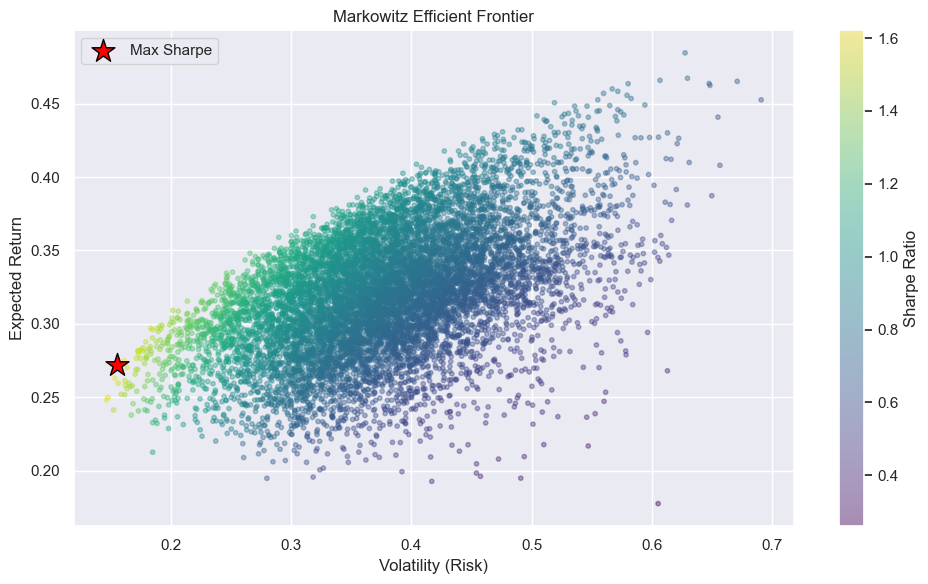


 --Hasil Alokasi Optimal-- 
Return Tahunan : 27.18%
Volatilitas    : 15.53%
Sharpe Ratio   : 1.62
-----------------------------
BTC-USD: 13.36%
ETH-USD: 1.38%
GLD: 50.05%
SOL-USD: 1.15%
SPY: 34.05%


In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

#Parameter dasar
ASSETS = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'GLD', 'SPY']
START_DATE = '2023-01-01'
END_DATE = '2026-06-01'
NUM_PORTFOLIOS = 10000
RISK_FREE_RATE = 0.02 

def fetch_data(assets, start, end):
    #Tarik data close price
    print("Downloading data...")
    data = yf.download(assets, start=start, end=end)['Close']
    return data.dropna()

def get_metrics(data):
    #Hitung return tahunan & covariance (asumsi 252 hari trading)
    log_returns = np.log(data / data.shift(1)).dropna()
    return log_returns.mean() * 252, log_returns.cov() * 252

def run_monte_carlo(expected_returns, cov_matrix, num_portfolios):
    print(f"Running Monte Carlo ({num_portfolios} iterasi)...")
    num_assets = len(expected_returns)
    results = np.zeros((3, num_portfolios))
    weights_record = []

    for i in range(num_portfolios):
        #Generate random weights (total harus 1.0)
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)
        weights_record.append(weights)

        #Hitung return, volatility, dan sharpe ratio
        port_return = np.sum(weights * expected_returns)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe = (port_return - RISK_FREE_RATE) / port_vol

        results[0, i] = port_return
        results[1, i] = port_vol
        results[2, i] = sharpe

    return results, weights_record

def main():
    sns.set_theme(style="darkgrid")
    
    data = fetch_data(ASSETS, START_DATE, END_DATE)
    returns, cov = get_metrics(data)
    results, weights_record = run_monte_carlo(returns, cov, NUM_PORTFOLIOS)

    #Cari titik optimal (Sharpe tertinggi)
    max_idx = np.argmax(results[2])
    opt_weights = weights_record[max_idx]
    opt_return = results[0, max_idx]
    opt_vol = results[1, max_idx]

    #Plotting
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        results[1, :], results[0, :], 
        c=results[2, :], cmap='viridis', 
        marker='o', s=10, alpha=0.4
    )
    plt.colorbar(scatter, label='Sharpe Ratio')
    
    #Tandai portofolio optimal
    plt.scatter(
        opt_vol, opt_return, 
        color='red', marker='*', s=300, edgecolor='black', 
        label='Max Sharpe'
    )

    plt.title('Markowitz Efficient Frontier')
    plt.xlabel('Volatility (Risk)')
    plt.ylabel('Expected Return')
    plt.legend()
    plt.tight_layout()
    plt.show()

    #Print hasil alokasi
    print("\n --Hasil Alokasi Optimal-- ")
    print(f"Return Tahunan : {opt_return*100:.2f}%")
    print(f"Volatilitas    : {opt_vol*100:.2f}%")
    print(f"Sharpe Ratio   : {results[2, max_idx]:.2f}")
    print("-----------------------------")
    for asset, weight in zip(data.columns, opt_weights):
        print(f"{asset}: {weight*100:.2f}%")

if __name__ == "__main__":
    main()

[*********************100%***********************]  5 of 5 completed

Running Monte Carlo (10000 iterasi)...
Menjalankan simulasi pertumbuhan modal...


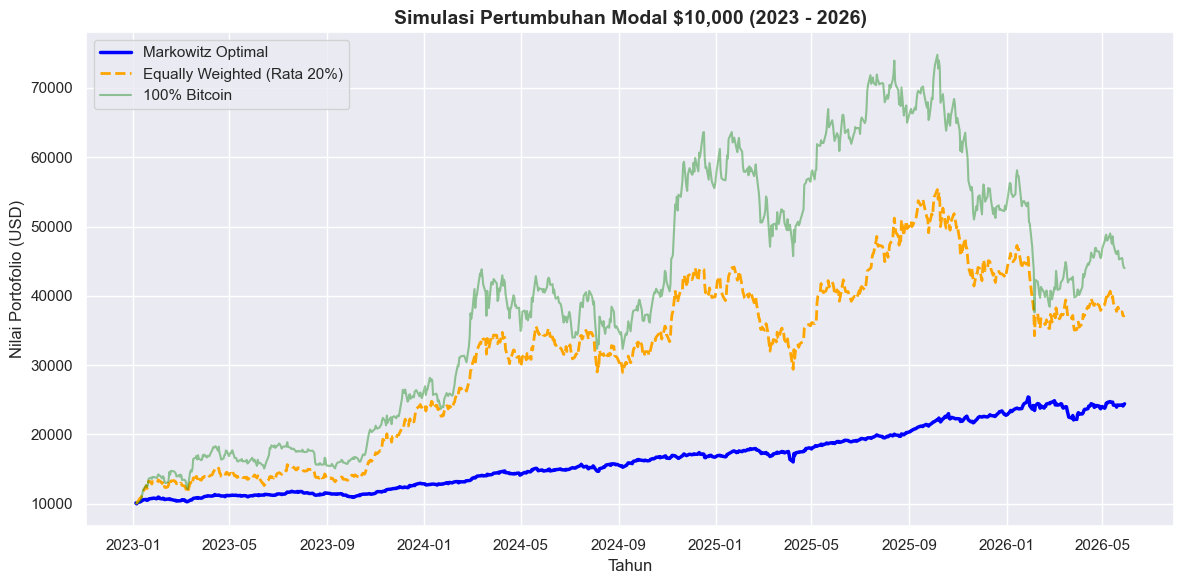


 HASIL AKHIR BACKTEST (Modal Awal: $10,000) 
Markowitz Optimal    : $24,406.08
Equally Weighted     : $37,188.73
100% Bitcoin         : $43,988.70


In [ ]:
# ==========================================
# 1. PARAMETER
# ==========================================
ASSETS = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'GLD', 'SPY']
START_DATE = '2023-01-01'
END_DATE = '2026-06-01'
NUM_PORTFOLIOS = 10000
RISK_FREE_RATE = 0.02
INITIAL_CAPITAL = 10000

sns.set_theme(style="darkgrid")

# ==========================================
# 2. TARIK DATA & HITUNG COVARIANCE
# ==========================================
print("Downloading data...")
data = yf.download(ASSETS, start=START_DATE, end=END_DATE)['Close'].dropna()

log_returns = np.log(data / data.shift(1)).dropna()
expected_returns = log_returns.mean() * 252
cov_matrix = log_returns.cov() * 252

# ==========================================
# 3. MONTE CARLO SIMULATION
# ==========================================
print(f"Running Monte Carlo ({NUM_PORTFOLIOS} iterasi)...")
num_assets = len(expected_returns)
results = np.zeros((3, NUM_PORTFOLIOS))
weights_record = []

for i in range(NUM_PORTFOLIOS):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    port_return = np.sum(weights * expected_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    results[0, i] = port_return
    results[1, i] = port_vol
    results[2, i] = (port_return - RISK_FREE_RATE) / port_vol

#Ekstrak bobot paling optimal
max_idx = np.argmax(results[2])
opt_weights = weights_record[max_idx]

# ==========================================
# 4. BACKTESTING & BENCHMARKING
# ==========================================
print("Menjalankan simulasi pertumbuhan modal...")
daily_returns = data.pct_change().dropna()

#Skenario 1: Markowitz Optimal
opt_daily_return = (daily_returns * opt_weights).sum(axis=1)
opt_eq = INITIAL_CAPITAL * (1 + opt_daily_return).cumprod()

#Skenario 2: Dibagi Rata (20% per aset)
eq_weights = np.array([1/len(data.columns)] * len(data.columns))
eq_daily_return = (daily_returns * eq_weights).sum(axis=1)
eq_eq = INITIAL_CAPITAL * (1 + eq_daily_return).cumprod()

#Skenario 3: 100% Bitcoin
btc_eq = INITIAL_CAPITAL * (1 + daily_returns['BTC-USD']).cumprod()

# ==========================================
# 5. VISUALISASI KURVA MODAL
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(opt_eq.index, opt_eq, label='Markowitz Optimal', color='blue', linewidth=2.5)
plt.plot(eq_eq.index, eq_eq, label='Equally Weighted (Rata 20%)', color='orange', linestyle='--', linewidth=2)
plt.plot(btc_eq.index, btc_eq, label='100% Bitcoin', color='green', alpha=0.4, linewidth=1.5)

plt.title('Simulasi Pertumbuhan Modal $10,000 (2023 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Portofolio (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# 6. OUTPUT HASIL AKHIR
# ==========================================
print("\n" + "="*45)
print(" HASIL AKHIR BACKTEST (Modal Awal: $10,000) ")
print("="*45)
print(f"Markowitz Optimal    : ${opt_eq.iloc[-1]:,.2f}")
print(f"Equally Weighted     : ${eq_eq.iloc[-1]:,.2f}")
print(f"100% Bitcoin         : ${btc_eq.iloc[-1]:,.2f}")
print("="*45)

Menghitung metrik Drawdown...


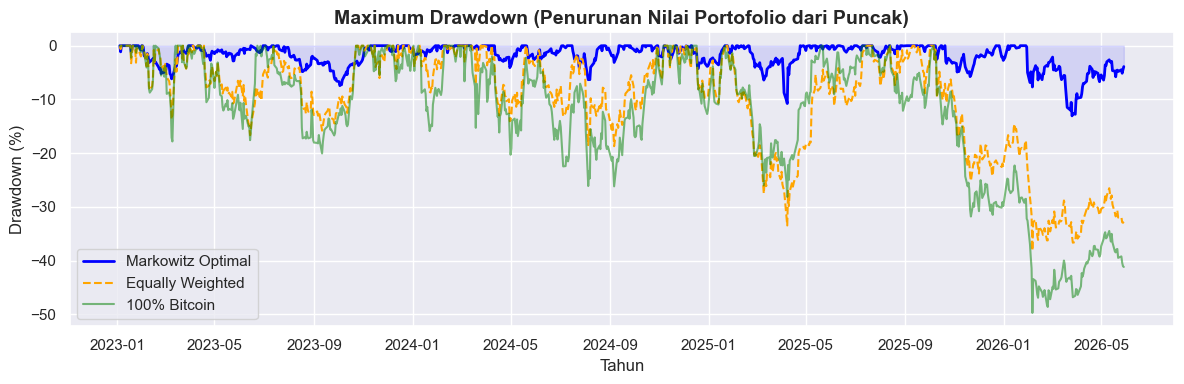


 MAXIMUM DRAWDOWN (Risiko Serangan Jantung) 
Markowitz Optimal    : -13.06%
Equally Weighted     : -38.14%
100% Bitcoin         : -49.74%


In [6]:
# ==========================================
# 7. MAXIMUM DRAWDOWN (Risiko Penurunan Terdalam)
# ==========================================
def calculate_drawdown(equity_curve):
    #Hitung titik puncak (peak) historis
    running_max = equity_curve.cummax()
    #Hitung persentase anjloknya harga dari puncak
    drawdown = (equity_curve - running_max) / running_max
    return drawdown

print("Menghitung metrik Drawdown...")
opt_dd = calculate_drawdown(opt_eq)
eq_dd = calculate_drawdown(eq_eq)
btc_dd = calculate_drawdown(btc_eq)

#Visualisasi Kurva Drawdown
plt.figure(figsize=(12, 4))
plt.plot(opt_dd.index, opt_dd * 100, label='Markowitz Optimal', color='blue', linewidth=2)
plt.plot(eq_dd.index, eq_dd * 100, label='Equally Weighted', color='orange', linestyle='--', linewidth=1.5)
plt.plot(btc_dd.index, btc_dd * 100, label='100% Bitcoin', color='green', alpha=0.5, linewidth=1.5)

plt.title('Maximum Drawdown (Penurunan Nilai Portofolio dari Puncak)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Drawdown (%)', fontsize=12)
plt.fill_between(opt_dd.index, opt_dd * 100, 0, color='blue', alpha=0.1)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Output Angka
print("\n" + "="*45)
print(" MAXIMUM DRAWDOWN (Risiko Serangan Jantung) ")
print("="*45)
print(f"Markowitz Optimal    : {opt_dd.min() * 100:.2f}%")
print(f"Equally Weighted     : {eq_dd.min() * 100:.2f}%")
print(f"100% Bitcoin         : {btc_dd.min() * 100:.2f}%")
print("="*45)